In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.stats.multitest
from sklearn.linear_model import LogisticRegression


pd.options.display.float_format = '{:.6f}'.format

In [3]:
df = pd.read_csv('metadata.csv', index_col=0)

In [4]:
df.head()

,Group_HC_dysplasia,Group_HC_LSIL_HSIL,Group_CIN,Age_atSampling,Menses_yesno,WeeksLastMenses,Gyn_problem_24hrs,Gyn_Intermittentbleeding,Gyn_Smell,Gyn_Itch,...,Intercourse24hrs,AB3months_sampling,HPV16,HPV16_HPV18_HPV45,HighRisk_HPV_type,PotentialHR_HPV,LowRisk_HPV,Group_HighRisk_LowRisk_NEG_HPV,num_reads,outcome
SampleID,,,,,,,,,,,,,,,,,,,,,
Dysp_0001,dysplasia,HSIL/cancer,cancer in situ,24,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1,1,1,0,1,HR_potHR,9958706.000000,1
Dysp_0002,dysplasia,HSIL/cancer,cancer in situ,52,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0,0,1,0,0,HR_potHR,7329914.000000,1
Dysp_0003,dysplasia,HSIL/cancer,cancer in situ,50,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1,1,1,0,0,HR_potHR,1136536.000000,1
Dysp_0004,dysplasia,HSIL/cancer,moderate,25,NaN,NaN,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,0,0,0,0,0,neg,8973572.000000,1
Dysp_0005,dysplasia,LSIL,NaN,31,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0,0,1,0,0,HR_potHR,14572788.000000,1


In [5]:
df[(df['HighRisk_HPV_type'] == 1) | (df['PotentialHR_HPV'] == 1)]['Group_HighRisk_LowRisk_NEG_HPV'].value_counts()

Group_HighRisk_LowRisk_NEG_HPV
HR_potHR    127
Name: count, dtype: int64

In [6]:
df[(df['HighRisk_HPV_type'] == 0) & (df['PotentialHR_HPV'] == 0)]['Group_HighRisk_LowRisk_NEG_HPV'].value_counts()

Group_HighRisk_LowRisk_NEG_HPV
neg         161
LR_other     66
Name: count, dtype: int64

In [7]:
df['Group_HighRisk_LowRisk_NEG_HPV'].value_counts()

Group_HighRisk_LowRisk_NEG_HPV
neg         161
HR_potHR    127
LR_other     66
Name: count, dtype: int64

In [8]:
results = []

for col in df.columns:
    if col in ['Group_HC_dysplasia', 'outcome','num_reads']:
        continue

    # Drop rows where either the outcome or the current variable is missing
    subset = df[['outcome', col]].replace('not applicable', np.nan).dropna()

    if col == 'Group_HighRisk_LowRisk_NEG_HPV':
        # excluding because this is just a grouping of exisiting columns as shown above
        continue

    if  (subset[col].nunique() > 2 and col not in  ['Age_atSampling','WeeksLastMenses']) or col == 'Group_CIN':
        # Categorical variable
        print('cat', col)

        formula = f'outcome ~ C({col})'
        try:
            model = smf.logit(formula=formula, data=subset).fit(disp=0)
            for term, coef, pval in zip(model.params.index, model.params.values, model.pvalues.values):
                if term == 'Intercept':
                    continue
                results.append({
                    'variable': col,
                    'term': term,
                    'effect_size': coef,
                    'p_value': pval
                })
        except Exception as e:
            print(f"Skipping {col} due to error: {e}")
    else:
        # Binary or continuous variable
        try:
            # X = subset[col]
            print('binary', col)
            X = sm.add_constant(subset[col])
            y = subset['outcome']
            model = sm.Logit(y, X).fit(disp=0)
            coef = model.params[col]
            pval = model.pvalues[col]

            if col != 'Age_atSampling':
                ntrue = subset[col].replace('Yes',1).replace('No',0).value_counts().loc[1]
                # if subset.value_counts().shape[0] != 4:
                #     print(col)
                #     print(subset.value_counts())

            else:
                ntrue = np.nan
            
            results.append({
                'variable': col,
                'term': col,
                'effect_size': coef,
                'p_value': pval,
                'n_true': ntrue
            })
        except Exception as e:
            print(f"Skipping {col} due to error: {e}")

# Compile results into a DataFrame
results_df = pd.DataFrame(results)

cat Group_HC_LSIL_HSIL
cat Group_CIN
binary Age_atSampling
binary Menses_yesno
binary WeeksLastMenses
binary Gyn_problem_24hrs
binary Gyn_Intermittentbleeding
binary Gyn_Smell
binary Gyn_Itch
binary Gyn_Pain
binary Gyn_Discharge
binary Gyn_BloodyDischarge
binary Gyn_Otherproblem24hrs
binary Intercourse24hrs
binary AB3months_sampling
binary HPV16
binary HPV16_HPV18_HPV45
binary HighRisk_HPV_type
binary PotentialHR_HPV
binary LowRisk_HPV


/opt/anaconda3/envs/basics/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/opt/anaconda3/envs/basics/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/opt/anaconda3/envs/basics/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/opt/anaconda3/envs/basics/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, categor

In [9]:
results_df = results_df.sort_values('p_value')
# results_df['p_BH_adj'] = statsmodels.stats.multitest.multipletests(results_df['p_value'], method='fdr_bh')[1]
results_df
# results_df.shape
results_df[results_df['p_value'] < 0.1]['variable'].tolist()


['LowRisk_HPV',
 'PotentialHR_HPV',
 'Gyn_problem_24hrs',
 'Menses_yesno',
 'Gyn_BloodyDischarge']

### Calculate propensity score

In [10]:
to_include = results_df[results_df['p_value'] < 0.1]['variable'].drop_duplicates().tolist()


In [11]:
df_propensity = df[['outcome'] + to_include]
df_propensity.shape

(354, 6)

In [12]:
df_propensity

,outcome,LowRisk_HPV,PotentialHR_HPV,Gyn_problem_24hrs,Menses_yesno,Gyn_BloodyDischarge
SampleID,,,,,,
Dysp_0001,1,1,0,0.000000,1.000000,0.000000
Dysp_0002,1,0,0,0.000000,1.000000,0.000000
Dysp_0003,1,0,0,0.000000,0.000000,0.000000
Dysp_0004,1,0,0,0.000000,NaN,0.000000
Dysp_0005,1,0,0,0.000000,1.000000,0.000000
...,...,...,...,...,...,...
VMG_0173,0,0,0,0.000000,1.000000,0.000000
VMG_0174,0,0,0,0.000000,0.000000,0.000000
VMG_0175,0,0,0,0.000000,0.000000,0.000000


### Imputing missing values

Gyn_problem_24hrs and Gyn_BloodyDischarge are missing data for the same set of 34 samples. 

Menses_yesno is missing data for 27 samples. 

These are all fairly sparse except menses yes/no. For menses yes/no I will impute 1 if Age_atSampling < 52 and 0 if Age_atSampling >= 52. The average age of menopause is 51-52. https://obgyn.onlinelibrary.wiley.com/doi/10.1111/1471-0528.17647


In [13]:
df_propensity.isna().sum(axis=0)

outcome                 0
LowRisk_HPV             0
PotentialHR_HPV         0
Gyn_problem_24hrs      34
Menses_yesno           24
Gyn_BloodyDischarge    34
dtype: int64

In [14]:
', '.join(df_propensity.columns)

'outcome, LowRisk_HPV, PotentialHR_HPV, Gyn_problem_24hrs, Menses_yesno, Gyn_BloodyDischarge'

In [15]:
df[['Menses_yesno',
 'Gyn_problem_24hrs',
 'Gyn_BloodyDischarge',
 ]]. apply(lambda x: x. value_counts(dropna=False)) 

,Menses_yesno,Gyn_problem_24hrs,Gyn_BloodyDischarge
0.000000,109,264,312
1.000000,221,56,8
NaN,24,34,34


In [16]:
df[['Menses_yesno',
 'Gyn_problem_24hrs',
 'Gyn_BloodyDischarge',
 ]]. apply(lambda x: x. value_counts(normalize=True, dropna=False)) 

,Menses_yesno,Gyn_problem_24hrs,Gyn_BloodyDischarge
0.000000,0.307910,0.745763,0.881356
1.000000,0.624294,0.158192,0.022599
NaN,0.067797,0.096045,0.096045


In [17]:
df[df['Age_atSampling'] > 52]['Menses_yesno'].value_counts()

Menses_yesno
0.000000    24
1.000000     1
Name: count, dtype: int64

In [18]:
df[df['Age_atSampling'] <= 52]['Menses_yesno'].value_counts()

Menses_yesno
1.000000    220
0.000000     85
Name: count, dtype: int64

In [19]:
for col in df_propensity.columns:

    if col == 'outcome':
        continue

    if df_propensity[col].isna().sum() > 0:
        # print(col)
        print(df_propensity[col].value_counts())
        print()

Gyn_problem_24hrs
0.000000    264
1.000000     56
Name: count, dtype: int64

Menses_yesno
1.000000    221
0.000000    109
Name: count, dtype: int64

Gyn_BloodyDischarge
0.000000    312
1.000000      8
Name: count, dtype: int64



Text(0, 0.5, '# participants')

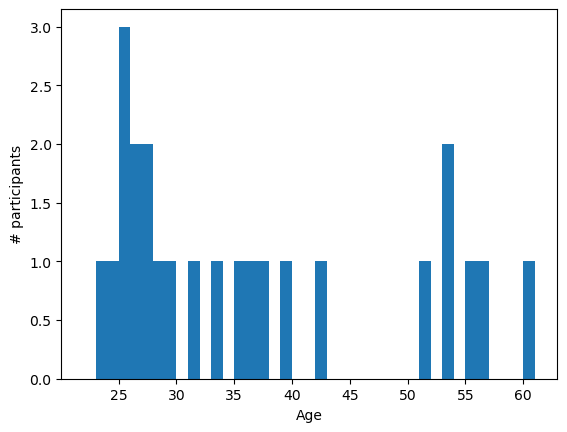

In [20]:
plt.hist(df[df['Menses_yesno'].isna()]['Age_atSampling'], bins=np.arange(22,62,1))
plt.xlabel('Age')
plt.ylabel('# participants')

In [21]:
df_propensity["Menses_yesno"] = np.where(
    df["Menses_yesno"].isna() & (df["Age_atSampling"] <= 52), 
    1,
    df_propensity["Menses_yesno"]
)

df_propensity["Menses_yesno"] = np.where(
    df["Menses_yesno"].isna() & (df["Age_atSampling"] > 52), 
    0,
    df_propensity["Menses_yesno"]
)

/var/folders/nh/_pzp_lps21jf91jy0p779fvm0000gn/T/ipykernel_6966/213009162.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_propensity["Menses_yesno"] = np.where(
/var/folders/nh/_pzp_lps21jf91jy0p779fvm0000gn/T/ipykernel_6966/213009162.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_propensity["Menses_yesno"] = np.where(


In [22]:
for col in df_propensity.columns:

    if col == 'outcome':
        continue

    if df_propensity[col].isna().sum() > 0:
        print(col)
        print(df_propensity[col].value_counts())
        print()
        df_propensity[col] = df_propensity[col].fillna(0)


Gyn_problem_24hrs
Gyn_problem_24hrs
0.000000    264
1.000000     56
Name: count, dtype: int64

Gyn_BloodyDischarge
Gyn_BloodyDischarge
0.000000    312
1.000000      8
Name: count, dtype: int64



/var/folders/nh/_pzp_lps21jf91jy0p779fvm0000gn/T/ipykernel_6966/337285583.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_propensity[col] = df_propensity[col].fillna(0)


In [159]:
X = df_propensity.drop(columns=['outcome'])
y = df_propensity['outcome']

logit = LogisticRegression(max_iter=1000, random_state=1)
logit.fit(X, y)

df_propensity['propensity_score'] = logit.predict_proba(X)[:, 1]
df_propensity

/var/folders/nh/_pzp_lps21jf91jy0p779fvm0000gn/T/ipykernel_39733/1863281211.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_propensity['propensity_score'] = logit.predict_proba(X)[:, 1]


,outcome,LowRisk_HPV,PotentialHR_HPV,Gyn_problem_24hrs,Menses_yesno,Gyn_BloodyDischarge,propensity_score
SampleID,,,,,,,
Dysp_0001,1,1,0,0.000000,1.000000,0.000000,0.735129
Dysp_0002,1,0,0,0.000000,1.000000,0.000000,0.401661
Dysp_0003,1,0,0,0.000000,0.000000,0.000000,0.478527
Dysp_0004,1,0,0,0.000000,1.000000,0.000000,0.401661
Dysp_0005,1,0,0,0.000000,1.000000,0.000000,0.401661
...,...,...,...,...,...,...,...
VMG_0173,0,0,0,0.000000,1.000000,0.000000,0.401661
VMG_0174,0,0,0,0.000000,0.000000,0.000000,0.478527
VMG_0175,0,0,0,0.000000,0.000000,0.000000,0.478527


In [160]:
df_propensity.to_csv('propensity_scores.csv')

In [161]:
from scipy import stats


def hosmer_lemeshow_test(y_true, y_pred, g=10):
    """Hosmer–Lemeshow test for logistic regression."""
    # Sort by predicted probability
    data = pd.DataFrame({'y_true': y_true, 'y_pred': y_pred})
    data['group'] = pd.qcut(data['y_pred'], q=g, duplicates='drop')

    # Calculate observed and expected counts
    obs = data.groupby('group')['y_true'].agg(['sum', 'count'])
    obs.rename(columns={'sum': 'observed'}, inplace=True)
    obs['expected'] = data.groupby('group')['y_pred'].sum()

    # HL statistic
    hl_stat = (((obs['observed'] - obs['expected'])**2) /
               (obs['expected'] * (1 - obs['expected'] / obs['count']))).sum()
    p_value = 1 - stats.chi2.cdf(hl_stat, g - 2)
    return hl_stat, p_value, obs

hl_stat, p_value, obs_table = hosmer_lemeshow_test(y, df_propensity['propensity_score'])

print(f"Hosmer–Lemeshow statistic: {hl_stat:.3f}")
print(f"P-value: {p_value:.3f}")
print("Observed vs Expected in groups:")
print(obs_table)

Hosmer–Lemeshow statistic: 2.678
P-value: 0.953
Observed vs Expected in groups:
                observed  count   expected
group                                     
(0.401, 0.479]       104    254 108.401871
(0.479, 0.525]        16     31  16.271498
(0.525, 0.739]        25     34  23.639906
(0.739, 0.957]        32     35  28.708194


/var/folders/nh/_pzp_lps21jf91jy0p779fvm0000gn/T/ipykernel_39733/3052377508.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs = data.groupby('group')['y_true'].agg(['sum', 'count'])
/var/folders/nh/_pzp_lps21jf91jy0p779fvm0000gn/T/ipykernel_39733/3052377508.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs['expected'] = data.groupby('group')['y_pred'].sum()
